# Importing Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import yfinance as yf

# Getting The Required Tickers

In [2]:
ticker = pd.read_csv('ind_nifty100list.csv') # Downloaded the Nifty 100 Index Contituent from nse website
ticker.head()

,Company Name,Industry,Symbol,Series,ISIN Code
0,ABB India Ltd.,Capital Goods,ABB,EQ,INE117A01022
1,Adani Energy Solutions Ltd.,Power,ADANIENSOL,EQ,INE931S01010
2,Adani Enterprises Ltd.,Metals & Mining,ADANIENT,EQ,INE423A01024
3,Adani Green Energy Ltd.,Power,ADANIGREEN,EQ,INE364U01010
4,Adani Ports and Special Economic Zone Ltd.,Services,ADANIPORTS,EQ,INE742F01042


In [3]:
ticker = ticker['Symbol'] # Just getting its tickers
ticker.shape # has 104  stocks ??

(104,)

In [4]:
pd.set_option('display.max_rows',104)
ticker.head(104) # Trying to find out the 4 odd stocks

0             ABB
1      ADANIENSOL
2        ADANIENT
3      ADANIGREEN
4      ADANIPORTS
5      ADANIPOWER
6       AMBUJACEM
7      APOLLOHOSP
8      ASIANPAINT
9           DMART
10       AXISBANK
11     BAJAJ-AUTO
12     BAJFINANCE
13     BAJAJFINSV
14     BAJAJHLDNG
15     BANKBARODA
16            BEL
17           BPCL
18     BHARTIARTL
19       BOSCHLTD
20      BRITANNIA
21        CGPOWER
22          CANBK
23       CHOLAFIN
24          CIPLA
25      COALINDIA
26     CUMMINSIND
27            DLF
28       DIVISLAB
29        DRREDDY
30     DUMMYVEDL1
31     DUMMYVEDL2
32     DUMMYVEDL3
33     DUMMYVEDL4
34      EICHERMOT
35        ETERNAL
36           GAIL
37       GODREJCP
38         GRASIM
39        HCLTECH
40        HDFCAMC
41       HDFCBANK
42       HDFCLIFE
43       HINDALCO
44            HAL
45     HINDUNILVR
46       HINDZINC
47        HYUNDAI
48      ICICIBANK
49            ITC
50       INDHOTEL
51            IOC
52           IRFC
53           INFY
54         INDIGO
55       J

In [5]:
filt = ticker.str.contains('DUMMY') # Stocks were named DUMMY 
ticker = ticker[~filt] #u Removing the odd stocks using the created filter

In [6]:
ticker.shape # making sure all the stocks are removed

(100,)

# Downloading The Dataset

In [7]:
ticker = list(x + '.NS' for x in ticker) # Converting the tickers to a list with .NS suffix
df = yf.download(tickers = list(ticker), period = '5y') # Downloading the data

[*********************100%***********************]  100 of 100 completed


In [8]:
df.head()

Price             Close                                           \
Ticker           ABB.NS ADANIENSOL.NS  ADANIENT.NS ADANIGREEN.NS   
2021-05-28  1553.583496           NaN  1299.443604   1238.949951   
2021-05-31  1631.910400           NaN  1313.110474   1268.199951   
2021-06-01  1655.770386           NaN  1412.818237   1271.050049   
2021-06-02  1662.908813           NaN  1543.002075   1299.800049   
2021-06-03  1654.499023           NaN  1579.264038   1286.900024   

Price                                                              \
Ticker     ADANIPORTS.NS ADANIPOWER.NS AMBUJACEM.NS APOLLOHOSP.NS   
2021-05-28    753.422302     18.389999   314.912323   3108.703369   
2021-05-31    747.015564     18.500000   316.024414   3127.853271   
2021-06-01    774.826660     19.070000   313.510193   3197.986084   
2021-06-02    787.737244     19.280001   320.182678   3231.349854   
2021-06-03    801.133057     20.150000   322.938690   3381.437500   

Price                                 ...        Volume                       \
Ticker     ASIANPAINT.NS AXISBANK.NS  ... TORNTPHARM.NS TRENT.NS TVSMOTOR.NS   
2021-05-28   2814.753174  736.773621  ...        159850   905813     4857631   
2021-05-31   2849.977295  747.578613  ...        207192  1296401     2432413   
2021-06-01   2805.468994  742.051697  ...        765228   697195     2654612   
2021-06-02   2779.337891  733.935547  ...        553158   826415     1687313   
2021-06-03   2809.632568  747.528809  ...        284992   404997     2252658   

Price                                                                 \
Ticker     ULTRACEMCO.NS UNIONBANK.NS UNITDSPR.NS   VBL.NS   VEDL.NS   
2021-05-28        285093     28013917         NaN  2381793  10107966   
2021-05-31        328449     21104866         NaN  1735807  11125660   
2021-06-01        397989     13024994         NaN  1502493  11911215   
2021-06-02        567704     26505584         NaN  3667106   9303223   
2021-06-03        349479     20258579         NaN  1127317  11241144   

Price                              
Ticker      WIPRO.NS ZYDUSLIFE.NS  
2021-05-28  11757252      6438083  
2021-05-31  10772410      4405464  
2021-06-01  11930088      3540399  
2021-06-02   9427136      5561507  
2021-06-03  11275982      4524635  

[5 rows x 500 columns]

In [9]:
df.shape

(1237, 500)

In [10]:
df = df['Close'] # Just wanna work with the closing values of stocks

In [11]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1237 entries, 2021-05-28 to 2026-05-27
Data columns (total 100 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ABB.NS         1237 non-null   float64
 1   ADANIENSOL.NS  686 non-null    float64
 2   ADANIENT.NS    1237 non-null   float64
 3   ADANIGREEN.NS  1237 non-null   float64
 4   ADANIPORTS.NS  1237 non-null   float64
 5   ADANIPOWER.NS  1237 non-null   float64
 6   AMBUJACEM.NS   1237 non-null   float64
 7   APOLLOHOSP.NS  1237 non-null   float64
 8   ASIANPAINT.NS  1237 non-null   float64
 9   AXISBANK.NS    1237 non-null   float64
 10  BAJAJ-AUTO.NS  1237 non-null   float64
 11  BAJAJFINSV.NS  1237 non-null   float64
 12  BAJAJHLDNG.NS  1237 non-null   float64
 13  BAJFINANCE.NS  1237 non-null   float64
 14  BANKBARODA.NS  1237 non-null   float64
 15  BEL.NS         1237 non-null   float64
 16  BHARTIARTL.NS  1237 non-null   float64
 17  BOSCHLTD.NS    1236 non-null   float64
 18  

# Trying To Findout Stocks Having More Than 5% Null Values And Cleaning The Dataset

In [12]:
filt = (df.isna().sum(axis = 'rows')/df.shape[0] * 100 > 5) # Creating a filter to check how many stockas have a null values which constitute more than 5% 
filt.sum() # Finding out the number of stocks 

np.int64(7)

In [13]:
df.drop(columns = df.columns[filt], inplace = True) # Removing the stocks with too muhc null values

In [14]:
df.shape

(1237, 93)

In [15]:
df.ffill(inplace = True)
df.head()

Ticker,ABB.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,...,TMPV.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
2021-05-28,1553.583496,1299.443604,1238.949951,753.422302,18.389999,314.912323,3108.703369,2814.753174,736.773621,3672.383057,...,313.112427,1274.000854,822.219116,605.808044,6420.261230,29.666443,88.251762,127.653351,248.852249,599.232971
2021-05-31,1631.910400,1313.110474,1268.199951,747.015564,18.500000,316.024414,3127.853271,2849.977295,747.578613,3666.524170,...,313.112427,1286.815918,847.136536,601.408875,6526.803223,29.968721,88.602135,131.464981,249.013916,596.339539
2021-06-01,1655.770386,1412.818237,1271.050049,774.826660,19.070000,313.510193,3197.986084,2805.468994,742.051697,3706.881592,...,312.473907,1307.610474,835.747070,598.964905,6423.034180,29.666443,88.177322,128.612244,250.746262,597.448730
2021-06-02,1662.908813,1543.002075,1299.800049,787.737244,19.280001,320.182678,3231.349854,2779.337891,733.935547,3755.939453,...,317.287231,1311.999390,848.628601,602.826416,6416.077148,30.443731,89.245911,131.944412,250.838638,605.116394
2021-06-03,1654.499023,1579.264038,1286.900024,801.133057,20.150000,322.938690,3381.437500,2809.632568,747.528809,3736.963867,...,319.890350,1302.705078,850.220032,610.891418,6462.294434,30.573280,90.038612,133.023178,249.013916,611.867676


# Starting The necessary Computations

In [16]:
df = df.pct_change() * 100 # Using pct_change in stock price to make correlation
df.head()

Ticker,ABB.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,...,TMPV.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
2021-05-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-31,5.041693,1.051748,2.360870,-0.850352,0.598155,0.353143,0.616009,1.251411,1.466528,-0.159539,...,0.000000,1.005891,3.030508,-0.726166,1.659465,1.018924,0.397015,2.985923,0.064965,-0.482856
2021-06-01,1.462089,7.593250,0.224736,3.722961,3.081079,-0.795578,2.242203,-1.561707,-0.739309,1.100700,...,-0.203927,1.615970,-1.344466,-0.406374,-1.589891,-1.008647,-0.479461,-2.169960,0.695682,0.186000
2021-06-02,0.431124,9.214479,2.261909,1.666254,1.101211,2.128315,1.043274,-0.931434,-1.093745,1.323427,...,1.540392,0.335644,1.541319,0.644697,-0.108314,2.620093,1.211863,2.590864,0.036841,1.283401
2021-06-03,-0.505728,2.350092,-0.992462,1.700543,4.512442,0.860762,4.644735,1.089996,1.852106,-0.505215,...,0.820430,-0.708408,0.187530,1.337865,0.720336,0.425536,0.888222,0.817591,-0.727449,1.115700


In [17]:
df.dropna(inplace = True) # Removing null values

In [18]:
df.shape

(1197, 93)

In [19]:
df = df.rolling(30).std() # Getting their volitility for 30 day windows
df.dropna(inplace = True)
df

Ticker,ABB.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,...,TMPV.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNIONBANK.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
2021-09-06,2.011810,2.106713,2.162457,1.804104,3.782809,1.524857,3.127567,1.360955,1.465801,1.134750,...,1.717943,1.460926,1.903761,1.515901,1.459965,1.912535,1.869507,3.589313,1.307763,1.737584
2021-09-07,2.012078,2.135853,2.007865,1.815313,3.866333,1.511923,3.097550,1.349685,1.503114,1.135388,...,1.720634,1.463596,1.922298,1.538083,1.440171,1.907784,1.884146,3.596082,1.325410,1.721544
2021-09-08,1.939617,2.131656,2.009345,1.713649,3.926531,1.537534,3.111490,1.326435,1.363533,1.153305,...,1.716820,1.384995,1.950933,1.549615,1.442073,1.908813,1.854467,3.559568,1.386511,1.716339
2021-09-09,1.926858,2.140741,2.097606,1.713594,4.001043,1.538583,3.127832,1.308851,1.344553,1.158255,...,1.666046,1.294982,1.966634,1.543662,1.446213,1.896391,1.833099,3.554192,1.387022,1.637279
2021-09-13,1.922046,2.150573,2.112050,1.707758,4.005528,1.542549,3.127256,1.304776,1.332864,1.130451,...,1.585153,1.263774,1.978279,1.486118,1.443772,1.421628,1.829258,3.371008,1.390709,1.631336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-21,2.486261,2.229396,2.270869,1.778123,2.397722,1.740140,1.167590,1.692059,1.281348,1.657646,...,2.062763,1.402837,1.887521,1.927297,1.292083,1.936337,1.977782,12.365695,1.450013,1.829734
2026-05-22,2.495083,2.219951,2.271890,1.777075,2.397072,1.659088,1.161466,1.693168,1.364410,1.665928,...,2.058748,1.382395,1.927925,1.935520,1.276930,1.942475,2.051835,12.351703,1.483445,1.825801
2026-05-25,2.406308,2.320579,2.257912,1.762824,2.597611,1.607065,1.161660,1.560030,1.338303,1.589386,...,2.055409,1.397603,1.912188,1.865357,1.281155,2.131723,2.086116,12.349607,1.510424,1.888069
2026-05-26,2.408432,2.384458,2.291998,1.744621,2.660677,1.628456,1.223208,1.560981,1.345211,1.594476,...,2.125688,1.497052,1.922096,1.812980,1.284105,2.101630,2.081664,12.377357,1.526656,1.887631


In [20]:
corr_mat = df.corr() # Getting the correlation stock

In [21]:
corr_mat = corr_mat.unstack() # Trying to get a combination of pairs of stocks

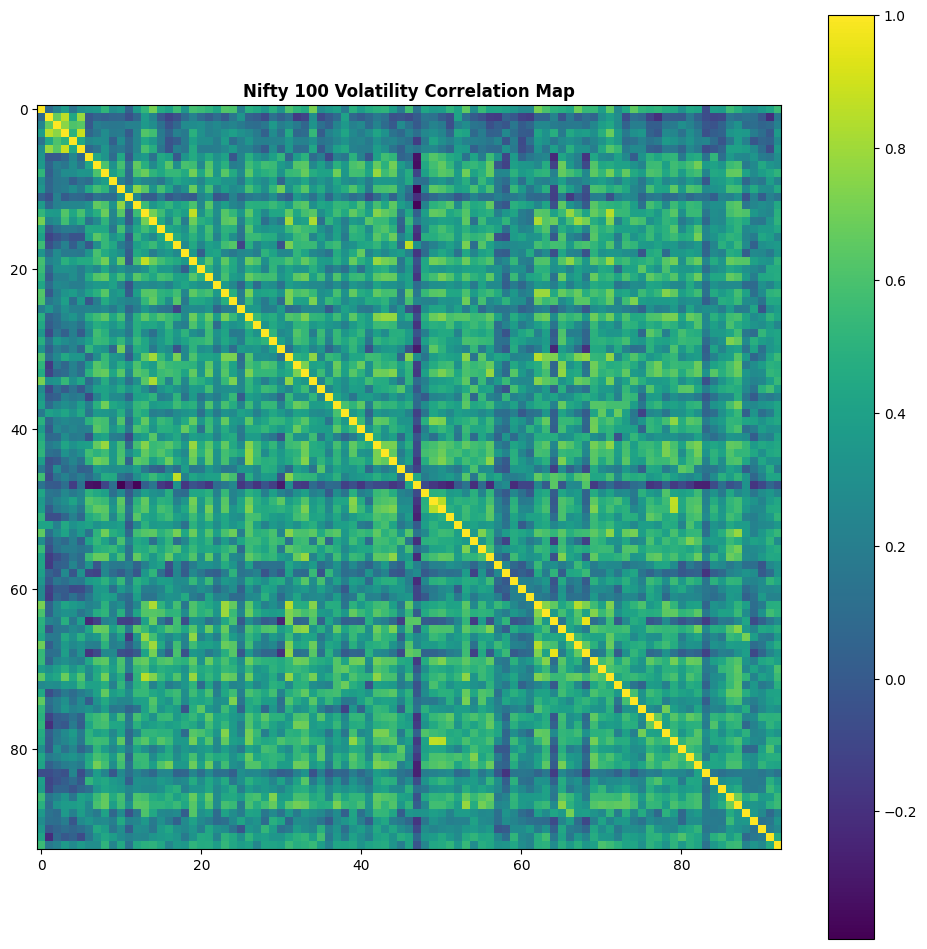

In [26]:
plt.figure(figsize = (12,12))
plt.imshow(df.corr())
plt.title('Nifty 100 Volatility Correlation Map', fontweight = 'bold')
plt.colorbar()
plt.show()

In [23]:
corr_mat = corr_mat[corr_mat.index.get_level_values(0) != corr_mat.index.get_level_values(1)] # Removing same pairing of stocks
corr_mat

Ticker        Ticker       
ABB.NS        ADANIENT.NS      0.088513
              ADANIGREEN.NS    0.237066
              ADANIPORTS.NS    0.375660
              ADANIPOWER.NS    0.142732
              AMBUJACEM.NS     0.294683
                                 ...   
ZYDUSLIFE.NS  ULTRACEMCO.NS    0.559222
              UNIONBANK.NS     0.236230
              VBL.NS           0.328547
              VEDL.NS          0.261533
              WIPRO.NS         0.462696
Length: 8556, dtype: float64

# Top 10 Stocks with high correlation in Nifty 100 with Examples

In [24]:
corr_mat.nlargest(20)[::2] # getting the 10 largest stock

Ticker         Ticker       
PFC.NS         RECLTD.NS        0.955919
ADANIPORTS.NS  AMBUJACEM.NS     0.883742
JINDALSTEL.NS  TATASTEEL.NS     0.868333
BPCL.NS        IOC.NS           0.867992
BANKBARODA.NS  CANBK.NS         0.867185
ADANIENT.NS    ADANIPORTS.NS    0.856324
JSWSTEEL.NS    TATASTEEL.NS     0.855271
BANKBARODA.NS  SBIN.NS          0.852140
JINDALSTEL.NS  JSWSTEEL.NS      0.849071
GAIL.NS        NTPC.NS          0.846679
dtype: float64

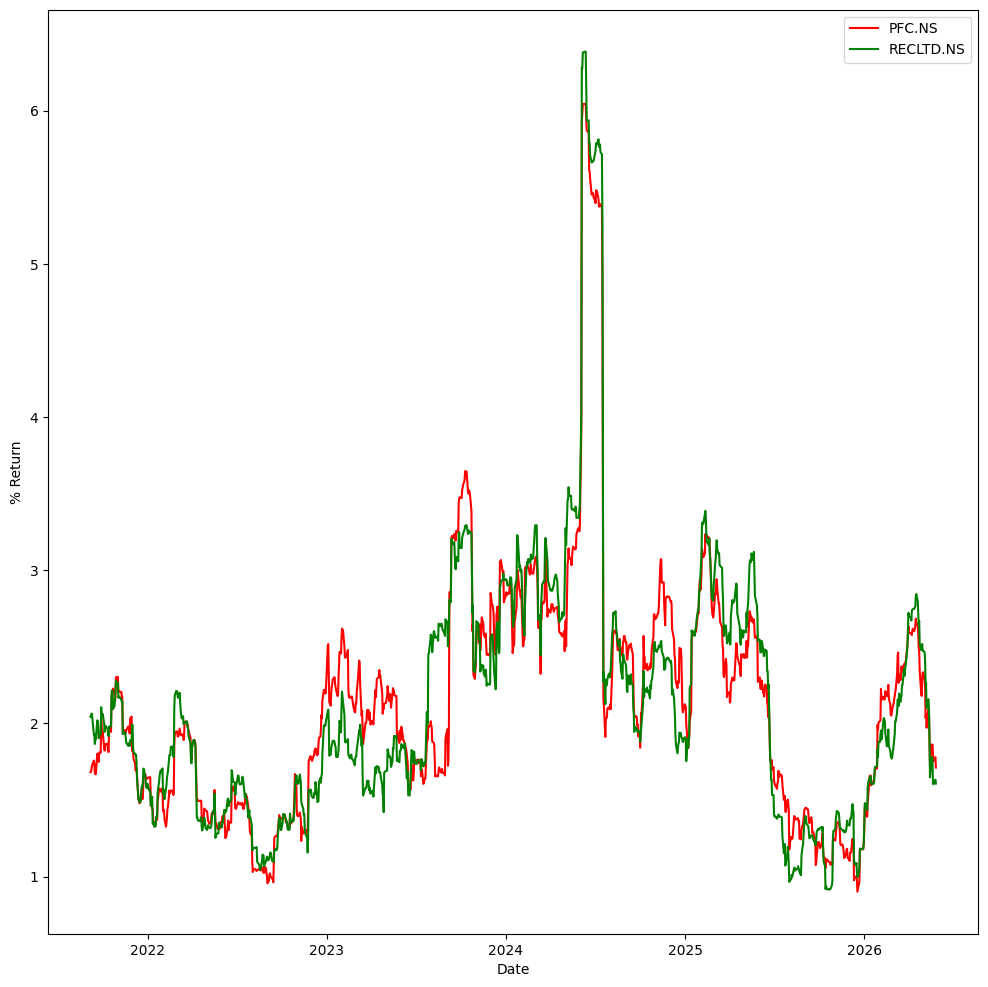

In [27]:
plt.figure(figsize = (12,12))
plt.plot(df['PFC.NS'], color = 'red')
plt.plot(df['RECLTD.NS'], color = 'green')
plt.legend(['PFC.NS','RECLTD.NS'])
plt.xlabel('Date')
plt.ylabel('% Return')
plt.show()

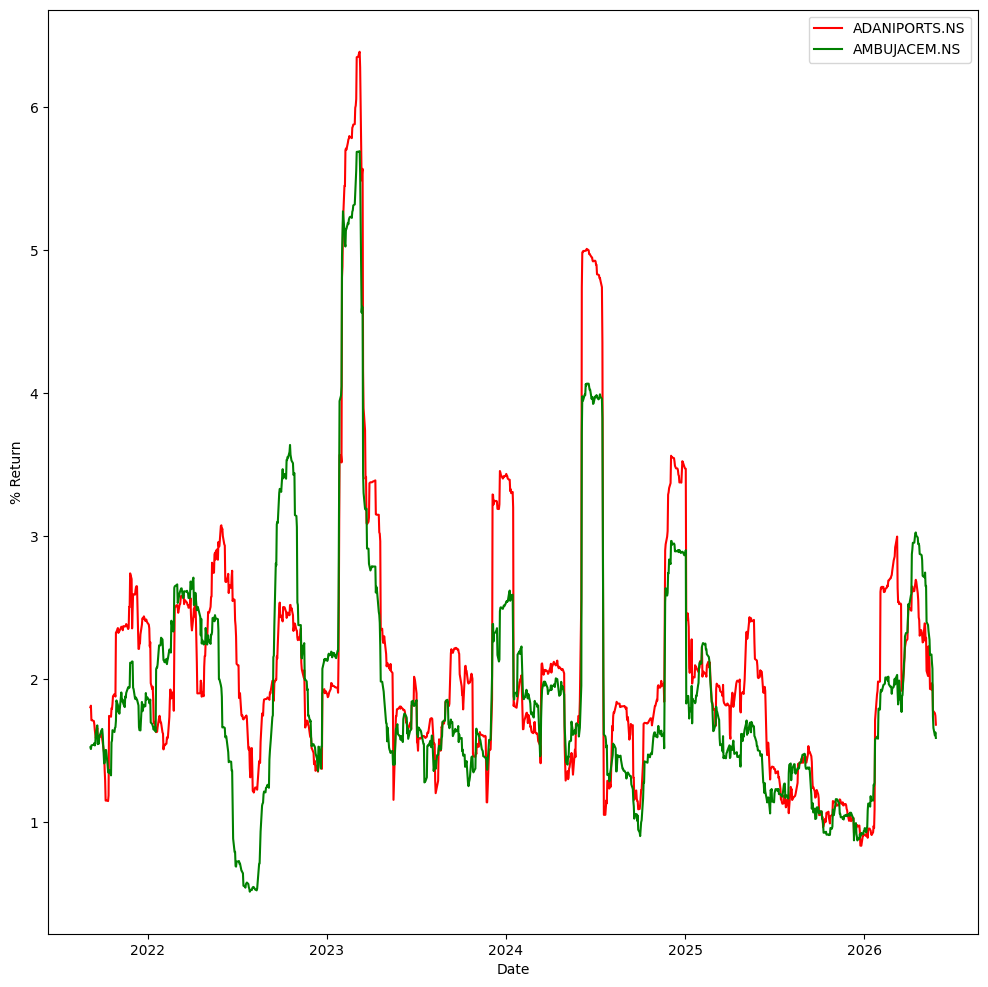

In [28]:
plt.figure(figsize = (12,12))
plt.plot(df['ADANIPORTS.NS'], color = 'red')
plt.plot(df['AMBUJACEM.NS'], color = 'green')
plt.legend(['ADANIPORTS.NS','AMBUJACEM.NS'])
plt.xlabel('Date')
plt.ylabel('% Return')
plt.show()